# Figure 3 v3: IFFL (type 2) with Cancer variable

Extends the IFFL model with a Cancer variable `C` whose dynamics depend on
whether the output `B` is above or below its homeostatic steady state.

$$
\frac{dA}{dt} = \beta_1\,u - \alpha_1\,A \qquad
\frac{dB}{dt} = \frac{\beta_2\,u}{A} - \alpha_2\,B \qquad
\frac{dC}{dt} = C\bigl(c_1 - c_2\,\max(B_{ss} - B,\,0)\bigr)
$$

- $B_{ss} = \dfrac{\beta_2\,\alpha_1}{\alpha_2\,\beta_1}$ (independent of $u$ — RPA)
- Cancer **decays** while $B < B_{ss}$ (output suppressed below steady state)
- Cancer **grows** at baseline rate $c_1$ when $B \geq B_{ss}$


In [ ]:
"""Setup: imports, shared parameters, IFFL + Cancer ODE, simulation helpers."""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.integrate import solve_ivp
import sys
sys.path.insert(0, '../src')
from rpa_control.style import set_style
from rpa_control.paths import save_fig

set_style()
plt.rcParams['text.usetex'] = False

# ── Plotting helpers ──────────────────────────────────────────────────

def clean_ax(ax):
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

# ── Shared IFFL parameters ────────────────────────────────────────────

PARAMS = dict(beta1=1.0, alpha1=1.0, beta2=1.0, alpha2=1.0)

# Cancer kinetics
C1_CANCER = 0.05   # baseline growth rate
C2_CANCER = 1.0    # kill rate when B is below B_ss

def B_ss_val(p=PARAMS):
    """Analytic steady state of B (independent of u — RPA)."""
    return p['beta2'] * p['alpha1'] / (p['alpha2'] * p['beta1'])

def steady_state(u, p=PARAMS):
    """Return (A_ss, B_ss) for a given input u."""
    A_ss = p['beta1'] * u / p['alpha1']
    return A_ss, B_ss_val(p)

# ── IFFL + Cancer ODE ─────────────────────────────────────────────────

B_SS = B_ss_val()  # fixed at baseline params

def iffl_cancer_rhs(t, state, u, p=PARAMS):
    """
    Right-hand side of the IFFL type-2 + Cancer system.

    state : [A, B, C]
    u     : current input (scalar or callable(t))
    """
    A, B, C = state
    u_val = u(t) if callable(u) else u
    dA = p['beta1'] * u_val - p['alpha1'] * A
    dB = p['beta2'] * u_val / A - p['alpha2'] * B
    dC = C * (C1_CANCER - C2_CANCER * max(B_SS - B, 0.0))
    return [dA, dB, dC]

# ── Simulation helper ─────────────────────────────────────────────────

def simulate(u, t_span, y0=None, n_pts=1000, p=PARAMS):
    """
    Integrate the IFFL+Cancer system.

    u     : constant float or callable(t)
    t_span: (t_start, t_end)
    y0    : [A0, B0, C0]; if None uses SS at constant u with C=1
    """
    if y0 is None:
        u0 = u(t_span[0]) if callable(u) else u
        A0, B0 = steady_state(u0, p)
        y0 = [A0, B0, 1.0]
    t_eval = np.linspace(*t_span, n_pts)
    sol = solve_ivp(
        lambda t, s: iffl_cancer_rhs(t, s, u, p),
        t_span, y0, t_eval=t_eval,
        method='Radau', rtol=1e-9, atol=1e-11, dense_output=True)
    return sol

print(f"B_ss = {B_SS:.4f}  (independent of u — RPA confirmed)")
print(f"Cancer: grows at c1={C1_CANCER}, decays at rate c2={C2_CANCER} when B < B_ss")


B_ss = 1.0000  (independent of u — RPA confirmed)
Cancer: grows at c1=0.05, decays at rate c2=1.0 when B < B_ss


/tmp/ipykernel_382714/3501482160.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


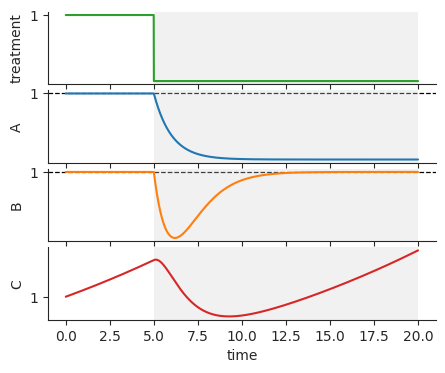

Figure saved to /home/amir/RL/autodiff-control/plots/figure3_V3_A.pdf


In [75]:
# Quick sanity check: abrupt u switch u=1→0.5, Cancer starting at 1
T_SWITCH = 5.0
T_END    = 20.0
A0, B0 = steady_state(1.0)
y0_init = [A0, B0, 1.0]

def u_func(t):
    return 0.5 if t >= T_SWITCH else 1.0

sol = simulate(u_func, (0, T_END), y0=y0_init, n_pts=2000)
t, (As, Bs, Cs) = sol.t, sol.y

fig, axes = plt.subplots(4, 1, figsize=(5, 4), sharex=True,
                          gridspec_kw={'hspace': 0.08})

ON_COLOR = 'lightgray'
for ax in axes:
    ax.axvspan(T_SWITCH, T_END, color=ON_COLOR, alpha=0.3, lw=0)
    clean_ax(ax)

# plot u(t) in the first subplot (line)
axes[0].plot(t, [u_func(ti) for ti in t], color='C2', lw=1.5, label='u(t)')
axes[0].set_ylabel('treatment')
axes[0].set_yticks([1.0])
axes[0].set_yticklabels(['1'])

axes[1].plot(t, As, color='C0', lw=1.5)
axes[1].axhline(1.0, color='k', ls='--', lw=0.9, zorder=-1)
axes[1].set_ylabel('A')
axes[1].set_yticks([1.0])
axes[1].set_yticklabels(['1'])

axes[2].plot(t, Bs, color='C1', lw=1.5)
axes[2].axhline(1.0, color='k', ls='--', lw=0.9, zorder=-1)
axes[2].set_ylabel('B')
# axes[2].legend(fontsize=8, frameon=False)
axes[2].set_yticks([1.0])
axes[2].set_yticklabels(['1'])

axes[3].plot(t, Cs, color='C3', lw=1.5)
axes[3].set_ylabel('C')
axes[3].set_xlabel('time')
axes[3].set_yticks([1.0])
axes[3].set_yticklabels(['1'])

plt.tight_layout()
plt.show()


save_fig(fig, 'figure3_V3_A.pdf')

/tmp/ipykernel_382714/1684587301.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


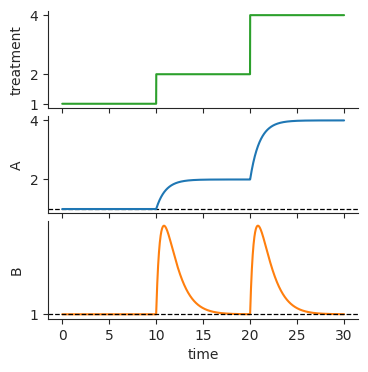

Figure saved to /home/amir/RL/autodiff-control/plots/figure3_V3_B.pdf


In [76]:
# Double switch sanity check: u=1→2 at t=10, then u=2→4 at t=20
T_SWITCH1 = 10.0
T_SWITCH2 = 20.0
T_END     = 30.0
A0, B0 = steady_state(1.0)
y0_init = [A0, B0, 1.0]

def u_func(t):
    if t < T_SWITCH1:
        return 1.0
    elif t < T_SWITCH2:
        return 2.0
    else:
        return 4.0

sol = simulate(u_func, (0, T_END), y0=y0_init, n_pts=2000)
t, (As, Bs, Cs) = sol.t, sol.y

fig, axes = plt.subplots(3, 1, figsize=(4, 4), sharex=True,
                          gridspec_kw={'hspace': 0.08})

ON_COLOR = 'lightgray'
for ax in axes:
    # ax.axvspan(T_SWITCH1, T_SWITCH2, color=ON_COLOR, alpha=0.3, lw=0)
    # ax.axvspan(T_SWITCH2, T_END,     color=ON_COLOR, alpha=0.5, lw=0)
    clean_ax(ax)

# plot u(t) line
axes[0].plot(t, [u_func(ti) for ti in t], color='C2', lw=1.5, label='u(t)')
axes[0].set_ylabel('treatment')
axes[0].set_yticks([1.0, 2.0, 4.0])
axes[0].set_yticklabels(['1', '2', '4'])

axes[1].plot(t, As, color='C0', lw=1.5)
axes[1].axhline(1.0, color='k', ls='--', lw=0.9, zorder=-1)
axes[1].set_ylabel('A')


axes[2].plot(t, Bs, color='C1', lw=1.5)
axes[2].axhline(B_SS, color='k', ls='--', lw=0.9)
axes[2].set_ylabel('B')
axes[2].set_xlabel('time')
axes[2].set_yticks([1.0])
axes[2].set_yticklabels(['1'])

plt.tight_layout()
plt.show()

save_fig(fig, 'figure3_V3_B.pdf')


/tmp/ipykernel_382714/578568031.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


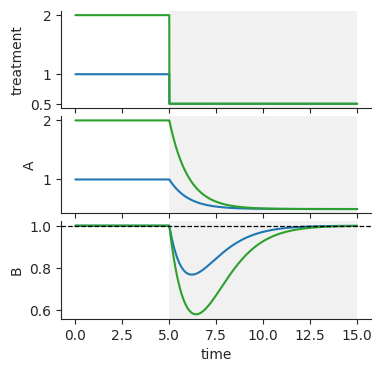

Figure saved to /home/amir/RL/autodiff-control/plots/figure3_V3_C.pdf


In [77]:
# Two starting points, same treatment: u → 0.5
# Each trajectory begins at its own SS for 5 time units, then switches.
T_PRE    = 5.0
T_END    = 15.0

cases = [
    dict(u_pre=1.0, color='C0', label='start $u=1$'),
    dict(u_pre=2.0, color='C2', label='start $u=2$'),
]
U_TREAT = 0.5

for c in cases:
    A0, B0 = steady_state(c['u_pre'])
    y0 = [A0, B0, 1.0]
    def u_func(t, u_pre=c['u_pre']):
        return U_TREAT if t >= T_PRE else u_pre
    sol = simulate(u_func, (0, T_END), y0=y0, n_pts=2000)
    c['t'] = sol.t
    c['A'] = sol.y[0]
    c['B'] = sol.y[1]
    c['u_arr'] = np.where(sol.t >= T_PRE, U_TREAT, c['u_pre'])

fig, axes = plt.subplots(3, 1, figsize=(4, 4), sharex=True,
                          gridspec_kw={'hspace': 0.08})

ON_COLOR = 'lightgray'
for ax in axes:
    ax.axvspan(T_PRE, T_END, color=ON_COLOR, alpha=0.3, lw=0)
    clean_ax(ax)

for c in cases:
    axes[0].plot(c['t'], c['u_arr'], color=c['color'], lw=1.5, label=c['label'])
    axes[1].plot(c['t'], c['A'],     color=c['color'], lw=1.5)
    axes[2].plot(c['t'], c['B'],     color=c['color'], lw=1.5)

axes[2].axhline(B_SS, color='k', ls='--', lw=0.9, label=f'$B_{{ss}}={B_SS:.2f}$')
# axes[2].legend(fontsize=8, frameon=False)

axes[0].set_ylabel('treatment')
axes[0].set_yticks([0.5, 1.0, 2.0])
axes[0].set_yticklabels(['0.5', '1', '2'])
axes[1].set_ylabel('A')
axes[2].set_ylabel('B')
axes[2].set_xlabel('time')

# axes[0].legend(fontsize=8, frameon=False)
# axes[0].set_title(f'Two starting points, same treatment u → {U_TREAT}', fontsize=9)
plt.tight_layout()
plt.show()

save_fig(fig, 'figure3_V3_C.pdf')


In [ ]:
# Gradual vs instant u: 1 → 2
# Gradual ramp mitigates the transient overshoot in B.
T_PRE  = 5.0
T_RAMP = 50.0
T_POST = 20.0
T_END  = T_PRE + T_RAMP + T_POST

U_START = 1.0
U_END   = 2.0

A0, B0 = steady_state(U_START)
y0 = [A0, B0, 1.0]

def u_instant(t):
    return U_END if t >= T_PRE else U_START

def u_gradual(t):
    if t < T_PRE:
        return U_START
    elif t < T_PRE + T_RAMP:
        return U_START + (U_END - U_START) * (t - T_PRE) / T_RAMP
    else:
        return U_END

cases = [
    dict(u_func=u_instant, color='C3', label='instant', ls='-'),
    dict(u_func=u_gradual, color='C0', label='gradual (10 t.u.)', ls='-'),
]

for c in cases:
    sol = simulate(c['u_func'], (0, T_END), y0=y0, n_pts=3000)
    c['t'] = sol.t
    c['A'] = sol.y[0]
    c['B'] = sol.y[1]
    c['C'] = sol.y[2]
    c['u_arr'] = np.array([c['u_func'](tt) for tt in sol.t])
    INTEG_WINDOW = 70.0
    mask = (c['t'] >= T_PRE) & (c['t'] <= T_PRE + INTEG_WINDOW)
    c['integral_B'] = np.trapz((c['B'] - B_SS)[mask], c['t'][mask])

fig, axes = plt.subplots(4, 1, figsize=(8, 8), sharex=True,
                          gridspec_kw={'hspace': 0.08})

for ax in axes:
    ax.axvspan(T_PRE, T_END, color='lightgray', alpha=0.35, lw=0)
    clean_ax(ax)

for c in cases:
    axes[0].plot(c['t'], c['u_arr'], color=c['color'], lw=1.5, label=c['label'])
    axes[1].plot(c['t'], c['A'],     color=c['color'], lw=1.5)
    axes[2].plot(c['t'], c['B'],     color=c['color'], lw=1.5)
    axes[3].plot(c['t'], c['C'],     color=c['color'], lw=1.5)

axes[2].axhline(B_SS, color='k', ls='--', lw=0.9, label=f'$B_{{ss}}={B_SS:.2f}$')

# Annotate integrals on the B panel
annot_lines = [rf"$\\int_{{0}}^{{10}}(B-B_{{{{ss}}}})\\,dt$ = {c['integral_B']:+.6f}  ({c['label']})" for c in cases]
axes[2].text(0.02, 0.97, '\n'.join(annot_lines),
             transform=axes[2].transAxes, fontsize=8,
             va='top', ha='left', family='monospace',
             bbox=dict(facecolor='white', alpha=0.75, edgecolor='none', boxstyle='round,pad=0.3'))
axes[2].legend(fontsize=8, frameon=False)

axes[0].set_ylabel('u(t)')
axes[1].set_ylabel('A(t)')
axes[2].set_ylabel('B(t)')
axes[3].set_ylabel('Cancer(t)')
axes[3].set_xlabel('time')

axes[0].legend(fontsize=8, frameon=False)
axes[0].set_title('Gradual vs instant u: 1 → 2  |  gradual ramp reduces B overshoot', fontsize=9)
plt.tight_layout()
plt.show()


In [79]:
def sensitization_strategy(params, parameter, baseline_value, prep_value, treat_value,
                            u_base=1.0, ramp_duration=20.0, t_post=30.0,
                            C0=1.0, n_pts=2000):
    """
    Two-stage sensitization + treatment for the IFFL+Cancer model.

    Stage 1 — preparation: linearly ramp `parameter` from baseline_value to
              prep_value over ramp_duration time units.
    Stage 2 — treatment: abruptly switch `parameter` to treat_value and
              integrate for t_post time units.

    A control trajectory is also computed: the baseline ODE runs for the
    full ramp_duration, then the same abrupt treatment is applied.

    Returns
    -------
    dict with keys:
        t_sens, y_sens   : full sensitized trajectory (3 × n array)
        t_ctrl, y_ctrl   : control trajectory
        param_arr        : parameter value at every sensitized time point
        t_switch         : time of the ramp-to-treatment switch (= ramp_duration)
        B_ss             : homeostatic steady-state of B at baseline params
        parameter, baseline_value, prep_value, treat_value
    """
    def resolve(param_val):
        """Return (u_val, p_eff) for the given value of `parameter`."""
        if parameter == 'u':
            return param_val, params
        return u_base, {**params, parameter: param_val}

    def make_rhs(param_val):
        u_val, p_eff = resolve(param_val)
        return lambda t, s: iffl_cancer_rhs(t, s, u_val, p_eff)

    # ── baseline steady state ─────────────────────────────────────────
    u0, p0    = resolve(baseline_value)
    A0, _     = steady_state(u0, p0)
    B_ss_base = B_ss_val(p0)
    state0    = [A0, B_ss_base, C0]

    n_ramp = max(int(n_pts * ramp_duration / (ramp_duration + t_post)), 100)
    n_post = max(n_pts - n_ramp, 100)

    # ── Stage 1: ramp (sensitized) ────────────────────────────────────
    def ramp_val(t):
        frac = min(t / ramp_duration, 1.0)
        return baseline_value + (prep_value - baseline_value) * frac

    def rhs_ramp(t, s):
        u_val, p_eff = resolve(ramp_val(t))
        return iffl_cancer_rhs(t, s, u_val, p_eff)

    t_ramp_arr = np.linspace(0, ramp_duration, n_ramp)
    sol_ramp   = solve_ivp(rhs_ramp, (0, ramp_duration), state0,
                            t_eval=t_ramp_arr, method='Radau', rtol=1e-9, atol=1e-11)

    # ── Stage 2: treatment (sensitized) ──────────────────────────────
    t_post_arr = np.linspace(ramp_duration, ramp_duration + t_post, n_post)
    sol_treat  = solve_ivp(make_rhs(treat_value),
                            (ramp_duration, ramp_duration + t_post),
                            sol_ramp.y[:, -1],
                            t_eval=t_post_arr, method='Radau', rtol=1e-9, atol=1e-11)

    # ── Control: baseline ODE during ramp, then treatment ────────────
    sol_ctrl_ramp  = solve_ivp(make_rhs(baseline_value), (0, ramp_duration), state0,
                                t_eval=t_ramp_arr, method='Radau', rtol=1e-9, atol=1e-11)
    t_ctrl_post    = np.linspace(ramp_duration, ramp_duration + t_post, n_post)
    sol_ctrl_treat = solve_ivp(make_rhs(treat_value),
                                (ramp_duration, ramp_duration + t_post),
                                sol_ctrl_ramp.y[:, -1],
                                t_eval=t_ctrl_post, method='Radau', rtol=1e-9, atol=1e-11)

    t_ctrl = np.concatenate([sol_ctrl_ramp.t, sol_ctrl_treat.t[1:]])
    y_ctrl = np.concatenate([sol_ctrl_ramp.y, sol_ctrl_treat.y[:, 1:]], axis=1)

    t_sens = np.concatenate([sol_ramp.t, sol_treat.t[1:]])
    y_sens = np.concatenate([sol_ramp.y, sol_treat.y[:, 1:]], axis=1)

    param_arr = np.concatenate([
        np.array([ramp_val(t) for t in sol_ramp.t]),
        np.full(len(sol_treat.t) - 1, treat_value),
    ])

    return dict(
        t_sens=t_sens, y_sens=y_sens,
        t_ctrl=t_ctrl, y_ctrl=y_ctrl,
        param_arr=param_arr,
        t_switch=ramp_duration,
        B_ss=B_ss_base,
        parameter=parameter,
        baseline_value=baseline_value,
        prep_value=prep_value,
        treat_value=treat_value,
    )


In [80]:
def plot_sensitization(res):
    """Plot B(t), Cancer(t), and parameter(t) for a sensitization result."""

    TREAT_COLOR = 'lightgray'

    t_sw  = res['t_switch']
    t_end = res['t_sens'][-1]

    fig, (ax_B, ax_C, ax_p) = plt.subplots(
        3, 1, figsize=(9, 7), sharex=True,
        gridspec_kw={'height_ratios': [2, 2, 1], 'hspace': 0.08})

    for ax in (ax_B, ax_C, ax_p):
        ax.axvspan(t_sw, t_end, color=TREAT_COLOR, alpha=0.4, lw=0)
        ax.axvline(t_sw, color='k', ls=':', lw=0.9, alpha=0.6)
        clean_ax(ax)

    # ── B(t) ──────────────────────────────────────────────────────────
    ax_B.plot(res['t_sens'], res['y_sens'][1], color='steelblue', lw=1.8, label='sensitized')
    ax_B.plot(res['t_ctrl'], res['y_ctrl'][1], color='tomato',    lw=1.8, ls='--', label='control')
    ax_B.axhline(res['B_ss'], color='k', ls='--', lw=1,
                 label=f"$B_{{ss}} = {res['B_ss']:.2f}$")
    ax_B.set_ylabel('B(t)')
    ax_B.legend(handles=[
        plt.Line2D([0],[0], color='steelblue', lw=1.8, label='sensitized'),
        plt.Line2D([0],[0], color='tomato',    lw=1.8, ls='--', label='control'),
        plt.Line2D([0],[0], color='k',         lw=1,   ls='--',
                   label=f"$B_{{ss}}={res['B_ss']:.2f}$"),
        mpatches.Patch(facecolor=TREAT_COLOR, alpha=0.6,
                       label=f"treat → {res['treat_value']:.3g}"),
    ], fontsize=8, frameon=False)

    # ── Cancer(t) ─────────────────────────────────────────────────────
    c_s = res['y_sens'][2]
    c_c = res['y_ctrl'][2]

    ax_C.plot(res['t_sens'], c_s, color='steelblue', lw=1.8)
    ax_C.plot(res['t_ctrl'], c_c, color='tomato',    lw=1.8, ls='--')
    ax_C.set_ylabel('Cancer(t)')

    n_treat = np.searchsorted(res['t_sens'], t_sw, side='right')
    stats = ('sensitized:  min=%.3f  final=%.3f\n'
             'control:     min=%.3f  final=%.3f') % (
             c_s[n_treat:].min(), c_s[-1], c_c[n_treat:].min(), c_c[-1])
    ax_C.text(0.02, 0.97, stats, transform=ax_C.transAxes,
              fontsize=7.5, ha='left', va='top', family='monospace',
              bbox=dict(facecolor='white', alpha=0.75, edgecolor='none',
                        boxstyle='round,pad=0.3'))

    # ── parameter(t) ──────────────────────────────────────────────────
    p_ctrl = np.where(res['t_ctrl'] <= t_sw,
                      res['baseline_value'], res['treat_value'])
    ax_p.plot(res['t_sens'], res['param_arr'], color='steelblue', lw=1.5)
    ax_p.plot(res['t_ctrl'], p_ctrl,           color='tomato',    lw=1.5, ls='--')
    ax_p.set_ylabel(res['parameter'])
    ax_p.set_xlabel('time')
    yticks = sorted({res['baseline_value'], res['prep_value'], res['treat_value']})
    ax_p.set_yticks(yticks)
    ax_p.set_yticklabels([f"{v:.3g}" for v in yticks], fontsize=7)

    fig.suptitle(
        f"Sensitization — {res['parameter']}: "
        f"{res['baseline_value']:.3g} → {res['prep_value']:.3g} → {res['treat_value']:.3g}",
        fontsize=10)
    plt.tight_layout()
    return fig


/tmp/ipykernel_382714/1219151977.py:65: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


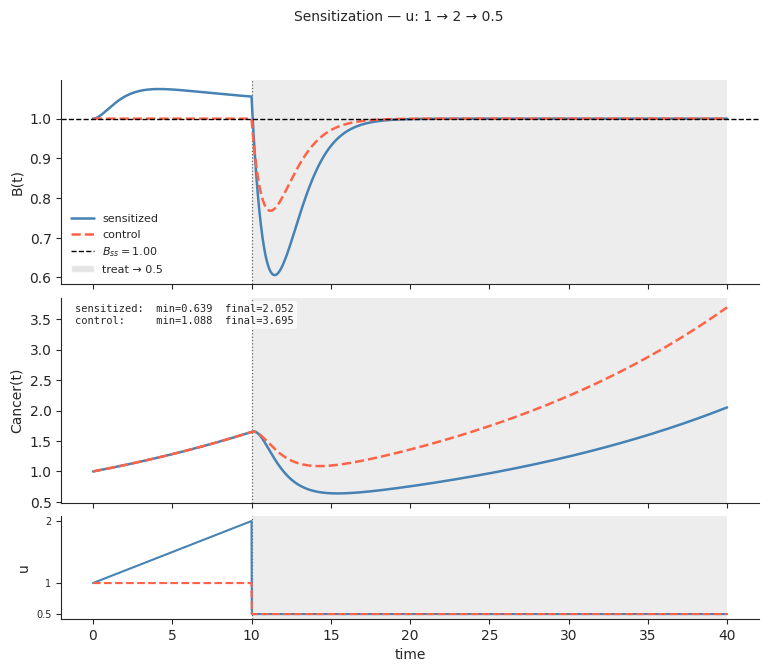

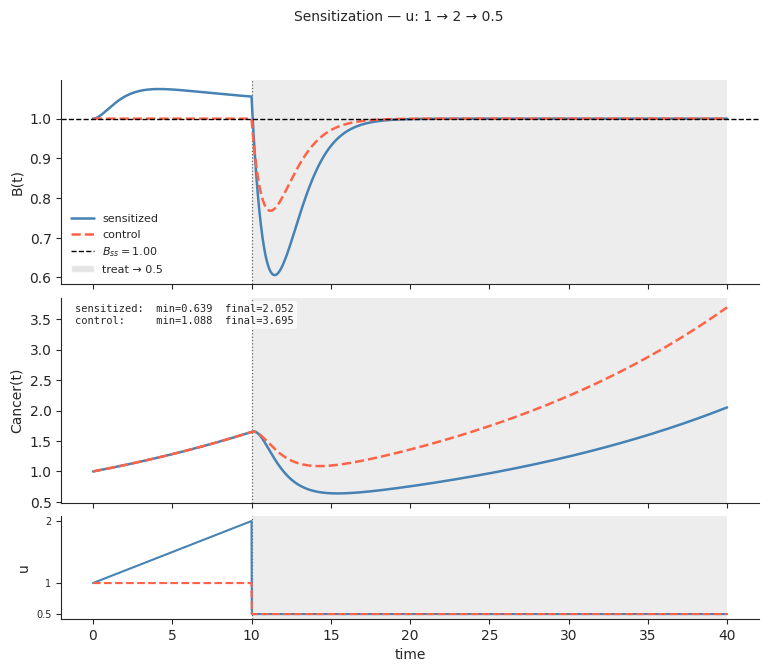

In [81]:
# Example
res = sensitization_strategy(
    PARAMS,
    parameter='u',
    baseline_value=1.0,
    prep_value=2.0,
    treat_value=0.5,
    ramp_duration=10.0,
    t_post=30.0,
)
plot_sensitization(res)
